In [29]:
import pandas as pd

In [30]:
df_crops = pd.read_csv('Corn vs Soybeans, Irrigated vs Non-Irrigated, County Level, 2000-2024.csv', on_bad_lines='skip')
df_drought = pd.read_csv('Drought data.csv', on_bad_lines='skip')

In [31]:
print("Crop data")
print(df_crops.head())
print("\nDrought Data")
print(df_drought.head())

Crop data
  Program  Year Period Geo Level     State  State ANSI Ag District  \
0  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
1  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
2  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
3  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
4  SURVEY  2024   YEAR    COUNTY  DELAWARE          10    SOUTHERN   

   Ag District Code          County County ANSI Commodity  \
0                99  OTHER COUNTIES         NaN      CORN   
1                99  OTHER COUNTIES         NaN      CORN   
2                99  OTHER COUNTIES         NaN  SOYBEANS   
3                99  OTHER COUNTIES         NaN  SOYBEANS   
4                80          SUSSEX           5      CORN   

                                           Data Item  Value  
0  CORN, GRAIN, IRRIGATED - YIELD, MEASURED IN BU...  217.9  
1  CORN, GRAIN, NON-IRRIGATED - YIELD, MEASURED I...  154.2  
2  SOYBEANS, IRR

In [32]:
df_crop_yields = df_crops[['Year', 'State', 'Commodity', 'Data Item', 'Value']]
# Gets the average yield in bushels/acre per state
df_crop_yields = df_crop_yields.groupby(['Year', 'State', 'Data Item'])['Value'].mean().reset_index()
# Create a pivot table to combine different data items (e.g. irrigated and non-irrigated) into the same row
df_crop_yields = df_crop_yields.pivot_table(index=['Year', 'State'], columns='Data Item', values='Value').reset_index()
df_crop_yields.columns.name = None
df_crop_yields.columns = ['Year', 'State', 'Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']
# Use State abbreviations
state_abbrev = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID',
    'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK',
    'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT',
    'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI', 'WYOMING': 'WY'
}
df_crop_yields['State'] = df_crop_yields['State'].map(state_abbrev)
print(df_crop_yields.head())

   Year State  Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  \
0  2000    WY             NaN          60.000000            NaN   
1  2007    AR             NaN                NaN      39.214286   
2  2007    CO      147.238095          56.794118            NaN   
3  2007    KS      167.000000         102.458333      50.384615   
4  2008    AR             NaN                NaN      40.166667   

   Soy_NonIrrigated  
0               NaN  
1         22.678571  
2               NaN  
3         32.960000  
4         27.727273  


In [33]:
#print(df_drought.columns)
df_drought_index = df_drought[['MapDate', 'State', 'D0', 'D1', 'D2', 'D3', 'D4']]
df_drought_index['Drought Index'] = (df_drought['D0'] * 1 + df_drought['D1'] * 2 + df_drought['D2'] * 3 + df_drought['D3'] * 4 + df_drought['D4'] * 5)
df_drought_index.drop(columns=['D0', 'D1', 'D2', 'D3', 'D4'], inplace=True)
df_drought_index['Year'] = df_drought_index['MapDate'].astype(str).str[:4].astype(int)  
df_drought_index.drop(columns=['MapDate'], inplace=True)  
df_drought_index = df_drought_index[['Year', 'State', 'Drought Index']]
df_drought_index = df_drought_index.groupby(['Year', 'State'])['Drought Index'].mean().reset_index()
# Get rid of Puerto Rico and DC
df_drought_index = df_drought_index[~df_drought_index['State'].isin(['DC', 'PR'])]
print(df_drought_index)

      Year State  Drought Index
0     2000    AK       2.308551
1     2000    AL     681.266472
2     2000    AR     228.927572
3     2000    AZ     104.065872
4     2000    CA       7.367921
...    ...   ...            ...
1399  2026    VT     124.284714
1400  2026    WA     130.533128
1401  2026    WI      92.511370
1402  2026    WV      77.340618
1403  2026    WY     370.614754

[1350 rows x 3 columns]


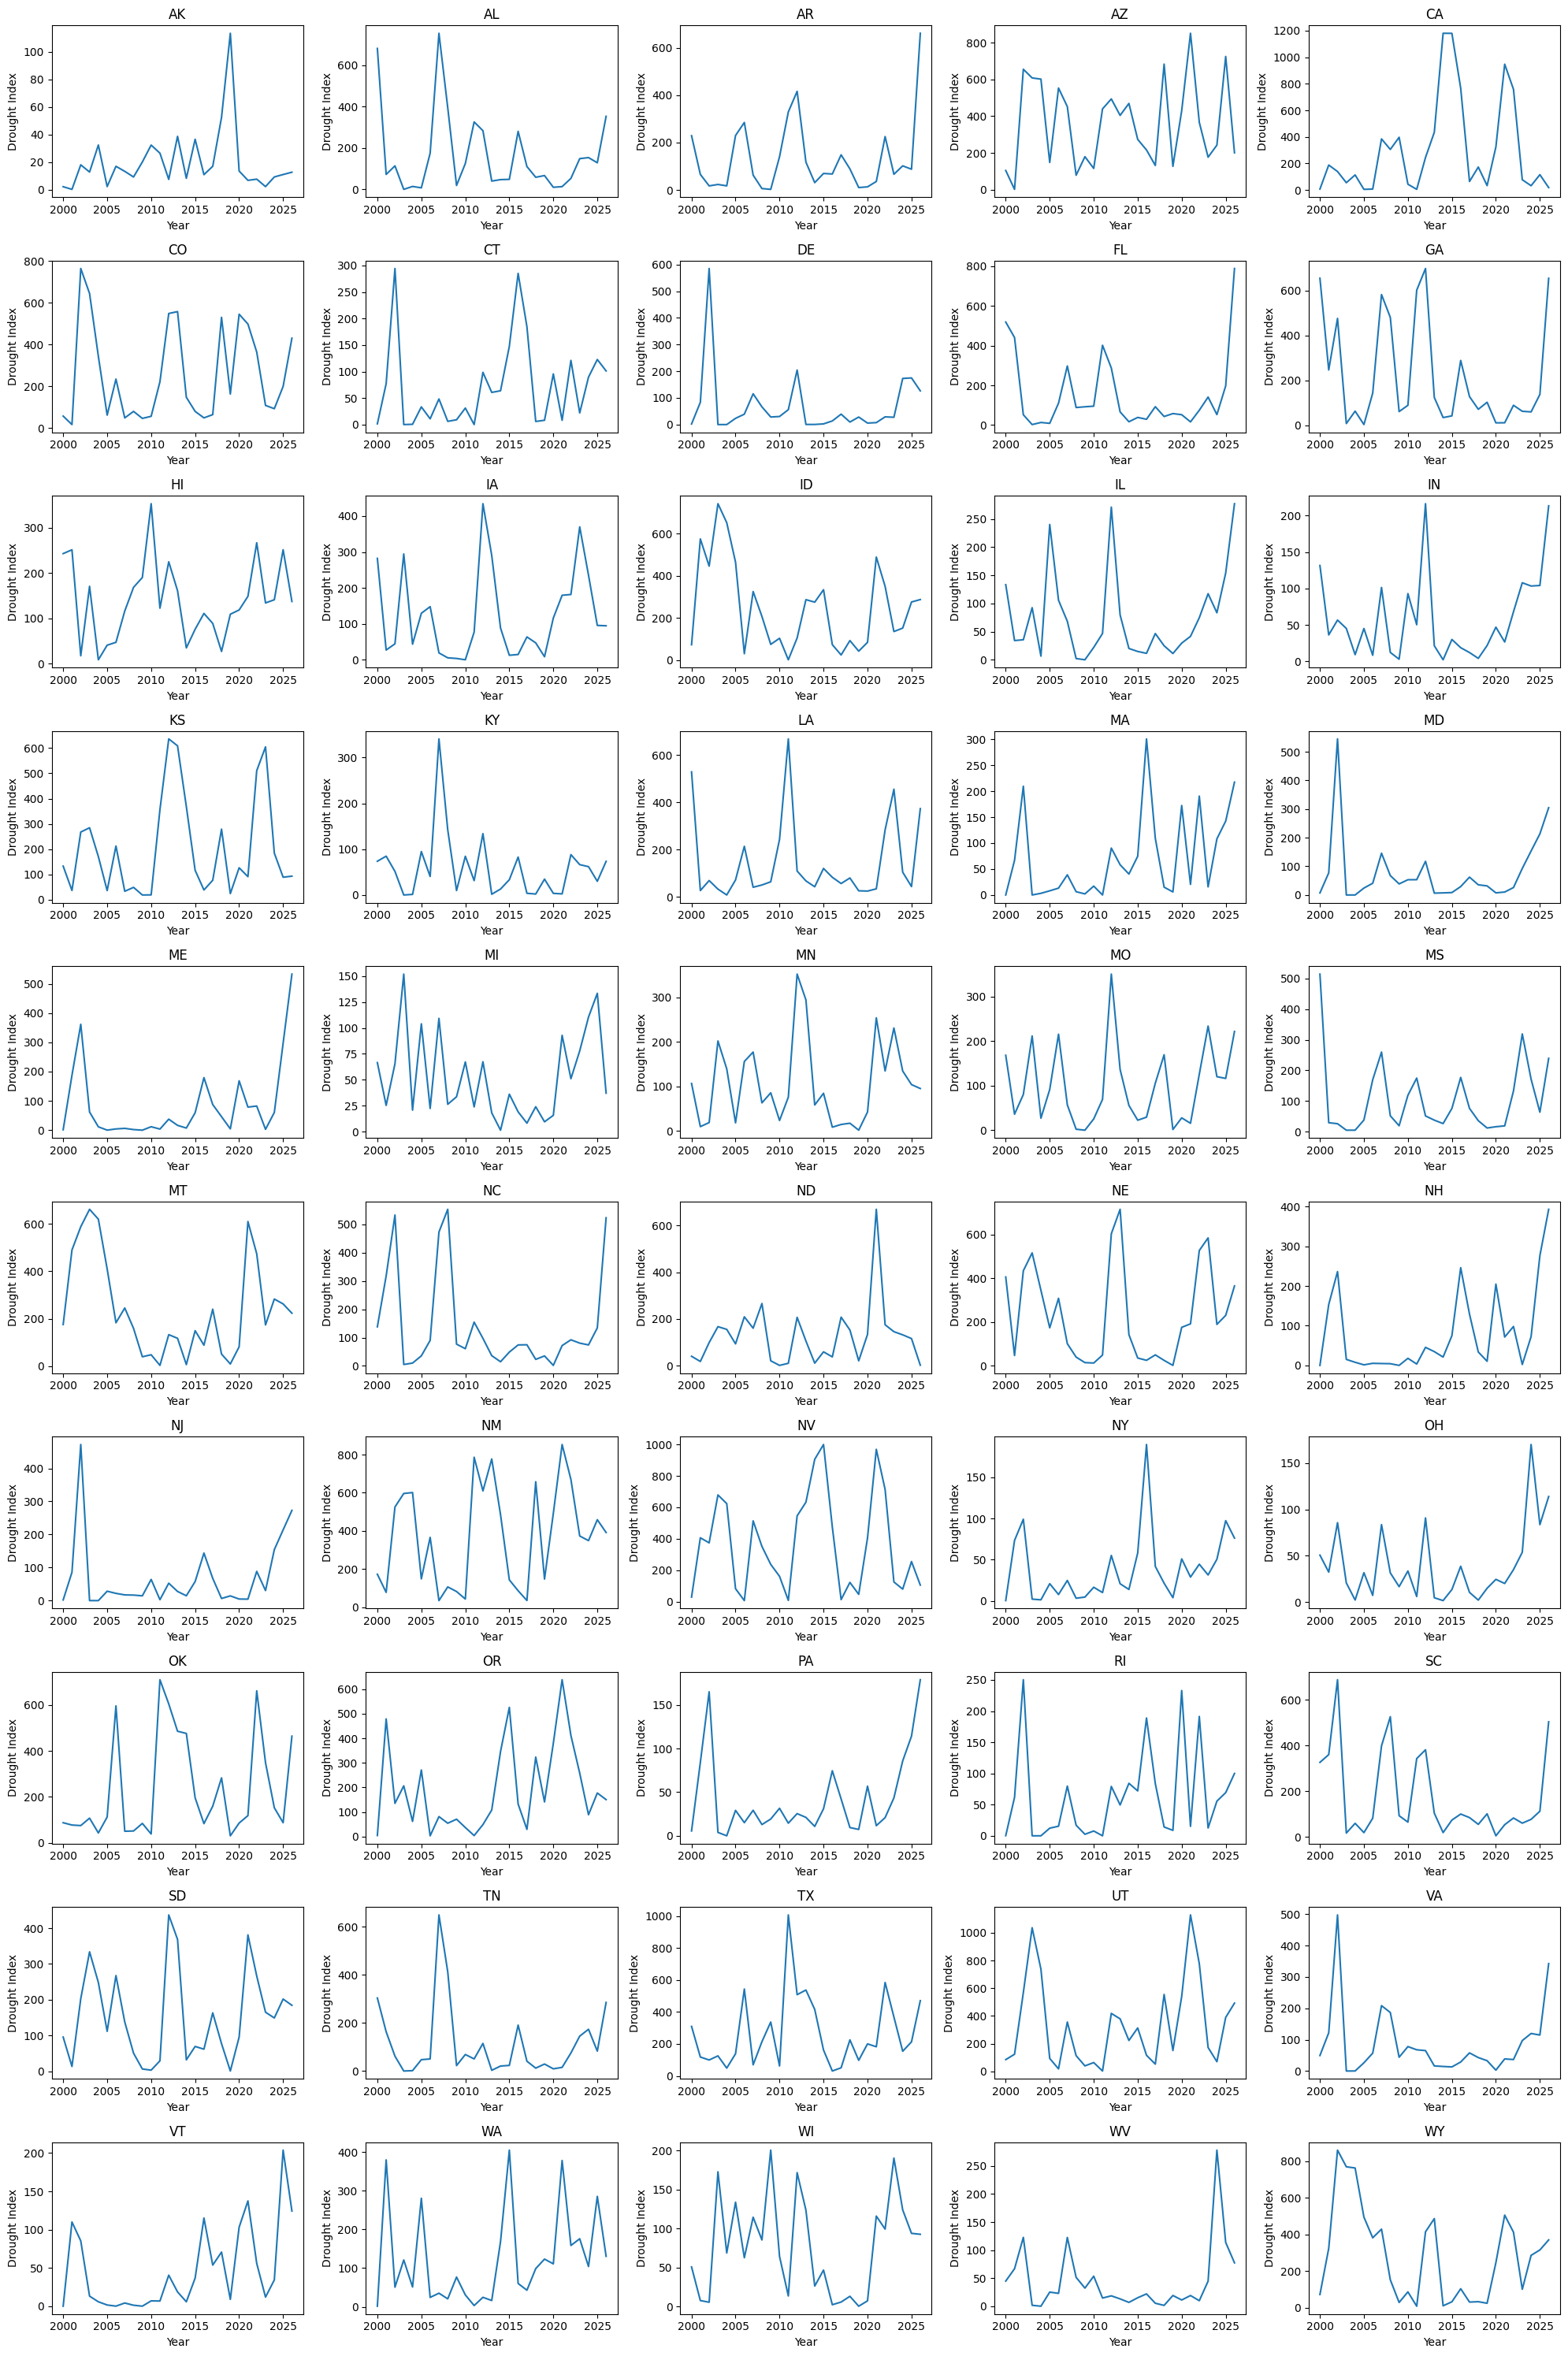

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 5, figsize=(20, 30))
axes = axes.flatten()

states = df_drought_index['State'].unique()

for i, state in enumerate(states):
    df_state = df_drought_index[df_drought_index['State'] == state]
    axes[i].plot(df_state['Year'], df_state['Drought Index'])
    axes[i].set_title(state)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Drought Index')

plt.tight_layout()
plt.show()

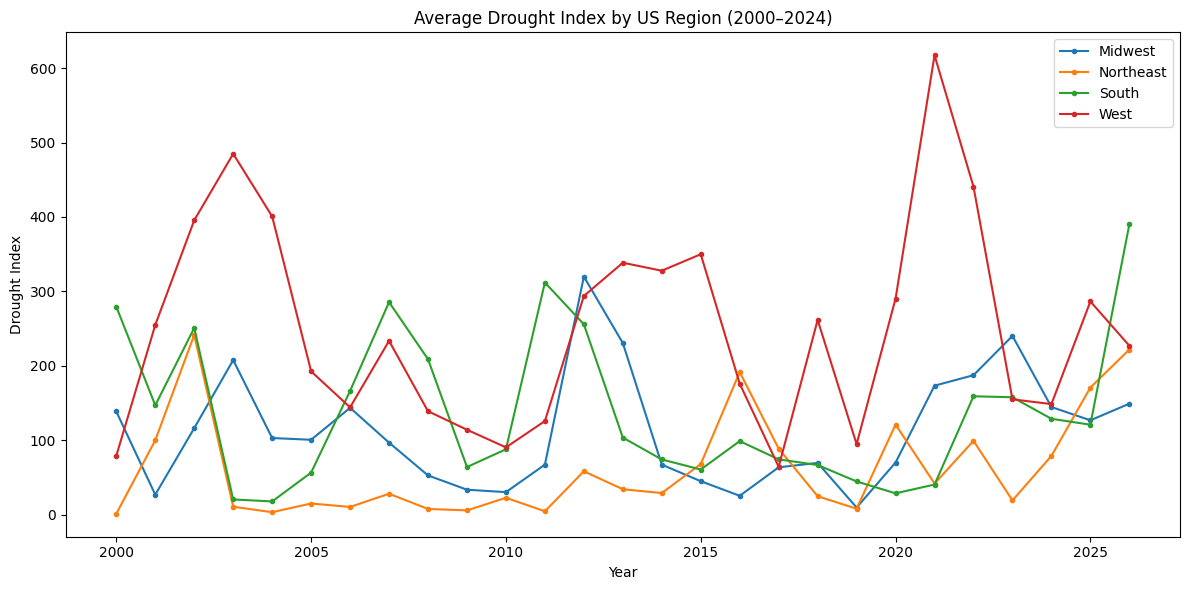

In [35]:

# Drought Index over time by US Census Region
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South',
    'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West',
}

df_drought_regional = df_drought_index.copy()
df_drought_regional['Region'] = df_drought_regional['State'].map(region_map)
df_drought_regional = df_drought_regional.dropna(subset=['Region'])
df_drought_regional = df_drought_regional.groupby(['Year', 'Region'])['Drought Index'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for region, group in df_drought_regional.groupby('Region'):
    ax.plot(group['Year'], group['Drought Index'], label=region, marker='o', markersize=3)

ax.set_title('Average Drought Index by US Region (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Drought Index')
ax.legend()
plt.tight_layout()
plt.show()


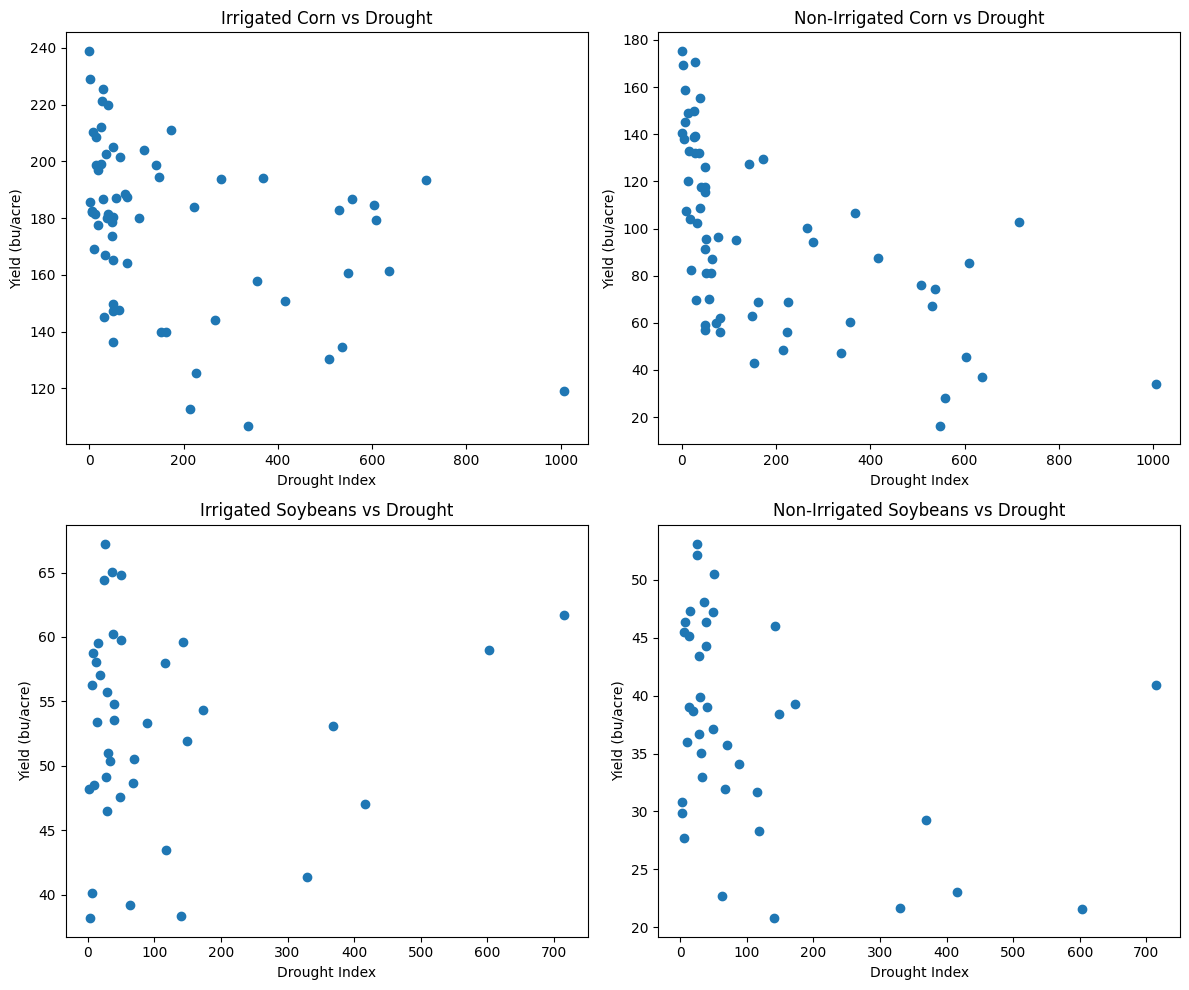

In [36]:
df_combined = df_crop_yields.merge(df_drought_index, on=['Year', 'State'])
#print(df_combined.head())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].scatter(df_combined['Drought Index'], df_combined['Corn_Irrigated'])
axes[0,0].set_title('Irrigated Corn vs Drought')
axes[0,0].set_xlabel('Drought Index')
axes[0,0].set_ylabel('Yield (bu/acre)')

axes[0,1].scatter(df_combined['Drought Index'], df_combined['Corn_NonIrrigated'])
axes[0,1].set_title('Non-Irrigated Corn vs Drought')
axes[0,1].set_xlabel('Drought Index')
axes[0,1].set_ylabel('Yield (bu/acre)')

axes[1,0].scatter(df_combined['Drought Index'], df_combined['Soy_Irrigated'])
axes[1,0].set_title('Irrigated Soybeans vs Drought')
axes[1,0].set_xlabel('Drought Index')
axes[1,0].set_ylabel('Yield (bu/acre)')

axes[1,1].scatter(df_combined['Drought Index'], df_combined['Soy_NonIrrigated'])
axes[1,1].set_title('Non-Irrigated Soybeans vs Drought')
axes[1,1].set_xlabel('Drought Index')
axes[1,1].set_ylabel('Yield (bu/acre)')

plt.tight_layout()
plt.show()

      Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Year                                                                    
2000             NaN          60.000000            NaN               NaN
2007      157.119048          79.626225      44.799451         27.819286
2008      155.310328          81.715323      47.097222         34.645532
2009      171.193045         107.441490      51.593208         38.636486
2010      173.438298          88.462842      48.214397         32.970131


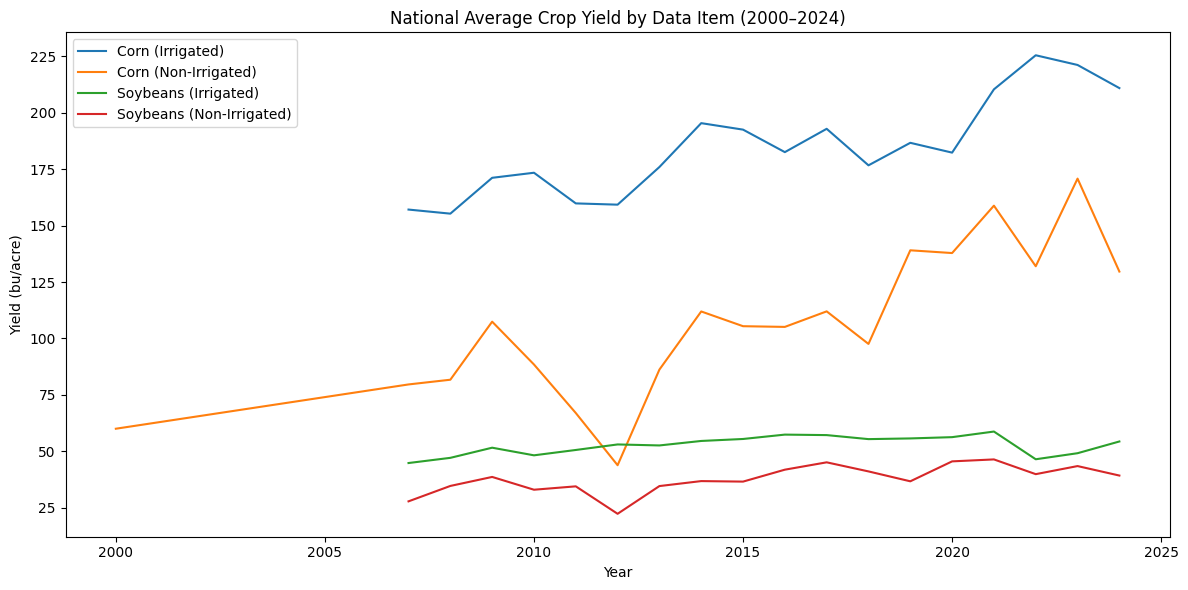

In [37]:
import matplotlib.pyplot as plt

# Average across all states per year
df_national = df_crop_yields.groupby('Year')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()
print(df_national.head())
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_national.index, df_national['Corn_Irrigated'], label='Corn (Irrigated)')
ax.plot(df_national.index, df_national['Corn_NonIrrigated'], label='Corn (Non-Irrigated)')
ax.plot(df_national.index, df_national['Soy_Irrigated'], label='Soybeans (Irrigated)')
ax.plot(df_national.index, df_national['Soy_NonIrrigated'], label='Soybeans (Non-Irrigated)')

ax.set_title('National Average Crop Yield by Data Item (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (bu/acre)')
ax.legend()
plt.tight_layout()
plt.show()


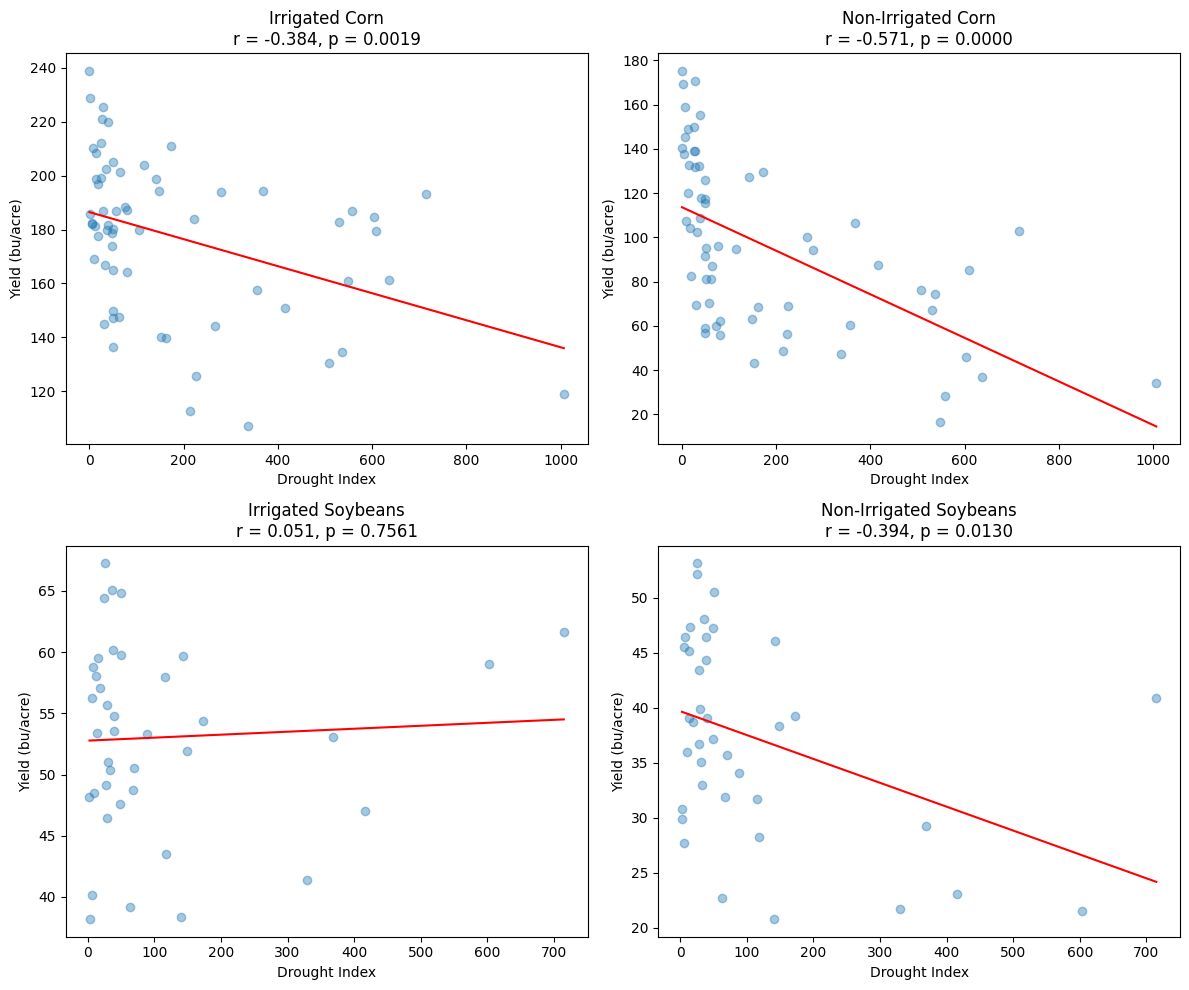

In [38]:
from scipy import stats
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
crop_labels = [
    ('Corn_Irrigated', 'Irrigated Corn'),
    ('Corn_NonIrrigated', 'Non-Irrigated Corn'),
    ('Soy_Irrigated', 'Irrigated Soybeans'),
    ('Soy_NonIrrigated', 'Non-Irrigated Soybeans'),
]

for ax, (col, label) in zip(axes.flatten(), crop_labels):
    subset = df_combined[['Drought Index', col]].dropna()
    x, y = subset['Drought Index'], subset[col]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    
    ax.scatter(x, y, alpha=0.4)
    ax.plot(np.sort(x), slope * np.sort(x) + intercept, color='red')
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlabel('Drought Index')
    ax.set_ylabel('Yield (bu/acre)')

plt.tight_layout()
plt.show()


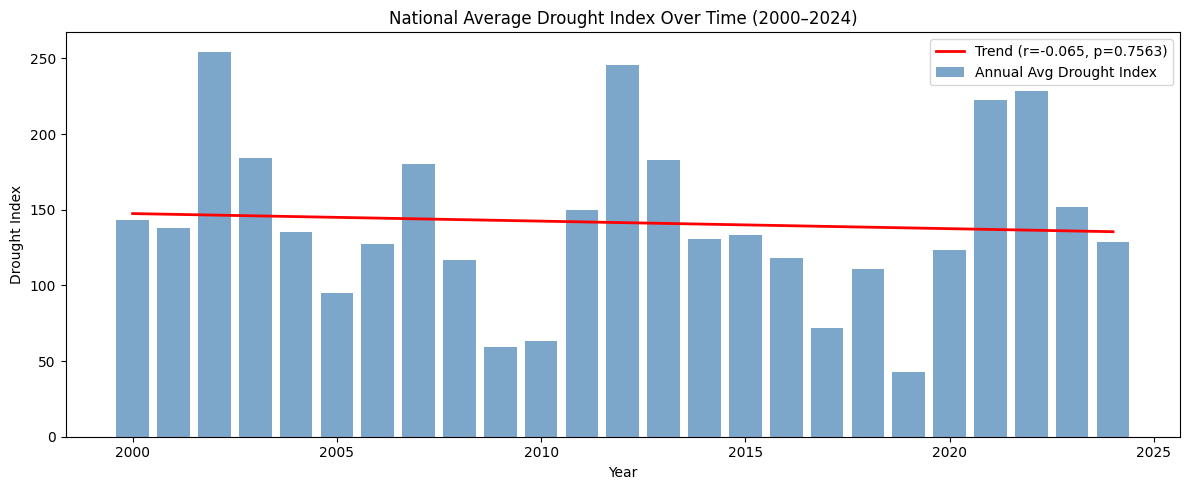

Trend slope: -0.50 index points/year
r = -0.065, p = 0.7563 — no significant trend


In [39]:
# Are droughts becoming more common over time?
df_trend = df_drought_index[df_drought_index['Year'] <= 2024]
df_trend = df_trend.groupby('Year')['Drought Index'].mean().reset_index()

slope, intercept, r, p, _ = stats.linregress(df_trend['Year'], df_trend['Drought Index'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_trend['Year'], df_trend['Drought Index'], color='steelblue', alpha=0.7, label='Annual Avg Drought Index')
ax.plot(df_trend['Year'], slope * df_trend['Year'] + intercept, color='red', linewidth=2, label=f'Trend (r={r:.3f}, p={p:.4f})')
ax.set_title('National Average Drought Index Over Time (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Drought Index')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trend slope: {slope:.2f} index points/year")
print(f"r = {r:.3f}, p = {p:.4f} — {'significant upward trend' if p < 0.05 and slope > 0 else 'no significant trend'}")


Pearson r by Region (negative = drought hurts yield):
Crop     Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Region                                                                     
Midwest          -0.229             -0.671          0.005            -0.540
South            -0.592             -0.657         -0.214            -0.526
West              0.001             -0.634            NaN               NaN


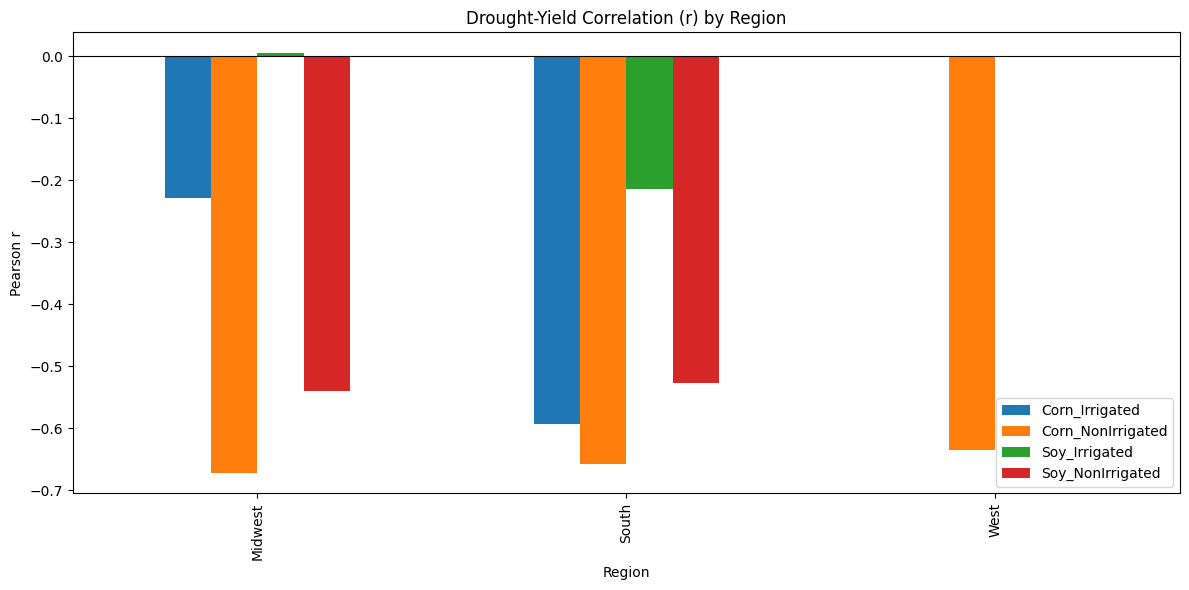

In [40]:
# Does the region matter? Drought-yield correlation by US Census Region
crops = ['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']

df_combined_region = df_combined.copy()
df_combined_region['Region'] = df_combined_region['State'].map(region_map)
df_combined_region = df_combined_region.dropna(subset=['Region'])

results = []
for region in df_combined_region['Region'].unique():
    df_r = df_combined_region[df_combined_region['Region'] == region]
    for crop in crops:
        subset = df_r[['Drought Index', crop]].dropna()
        if len(subset) < 5:
            continue
        r, p = stats.pearsonr(subset['Drought Index'], subset[crop])
        results.append({'Region': region, 'Crop': crop, 'r': r, 'p': p, 'n': len(subset)})

df_regions_correlations = pd.DataFrame(results).pivot(index='Region', columns='Crop', values='r').round(3)
print("Pearson r by Region (negative = drought hurts yield):")
print(df_regions_correlations.to_string())

df_regions_correlations.plot(kind='bar', figsize=(12, 6))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Drought-Yield Correlation (r) by Region')
plt.ylabel('Pearson r')
plt.xlabel('Region')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


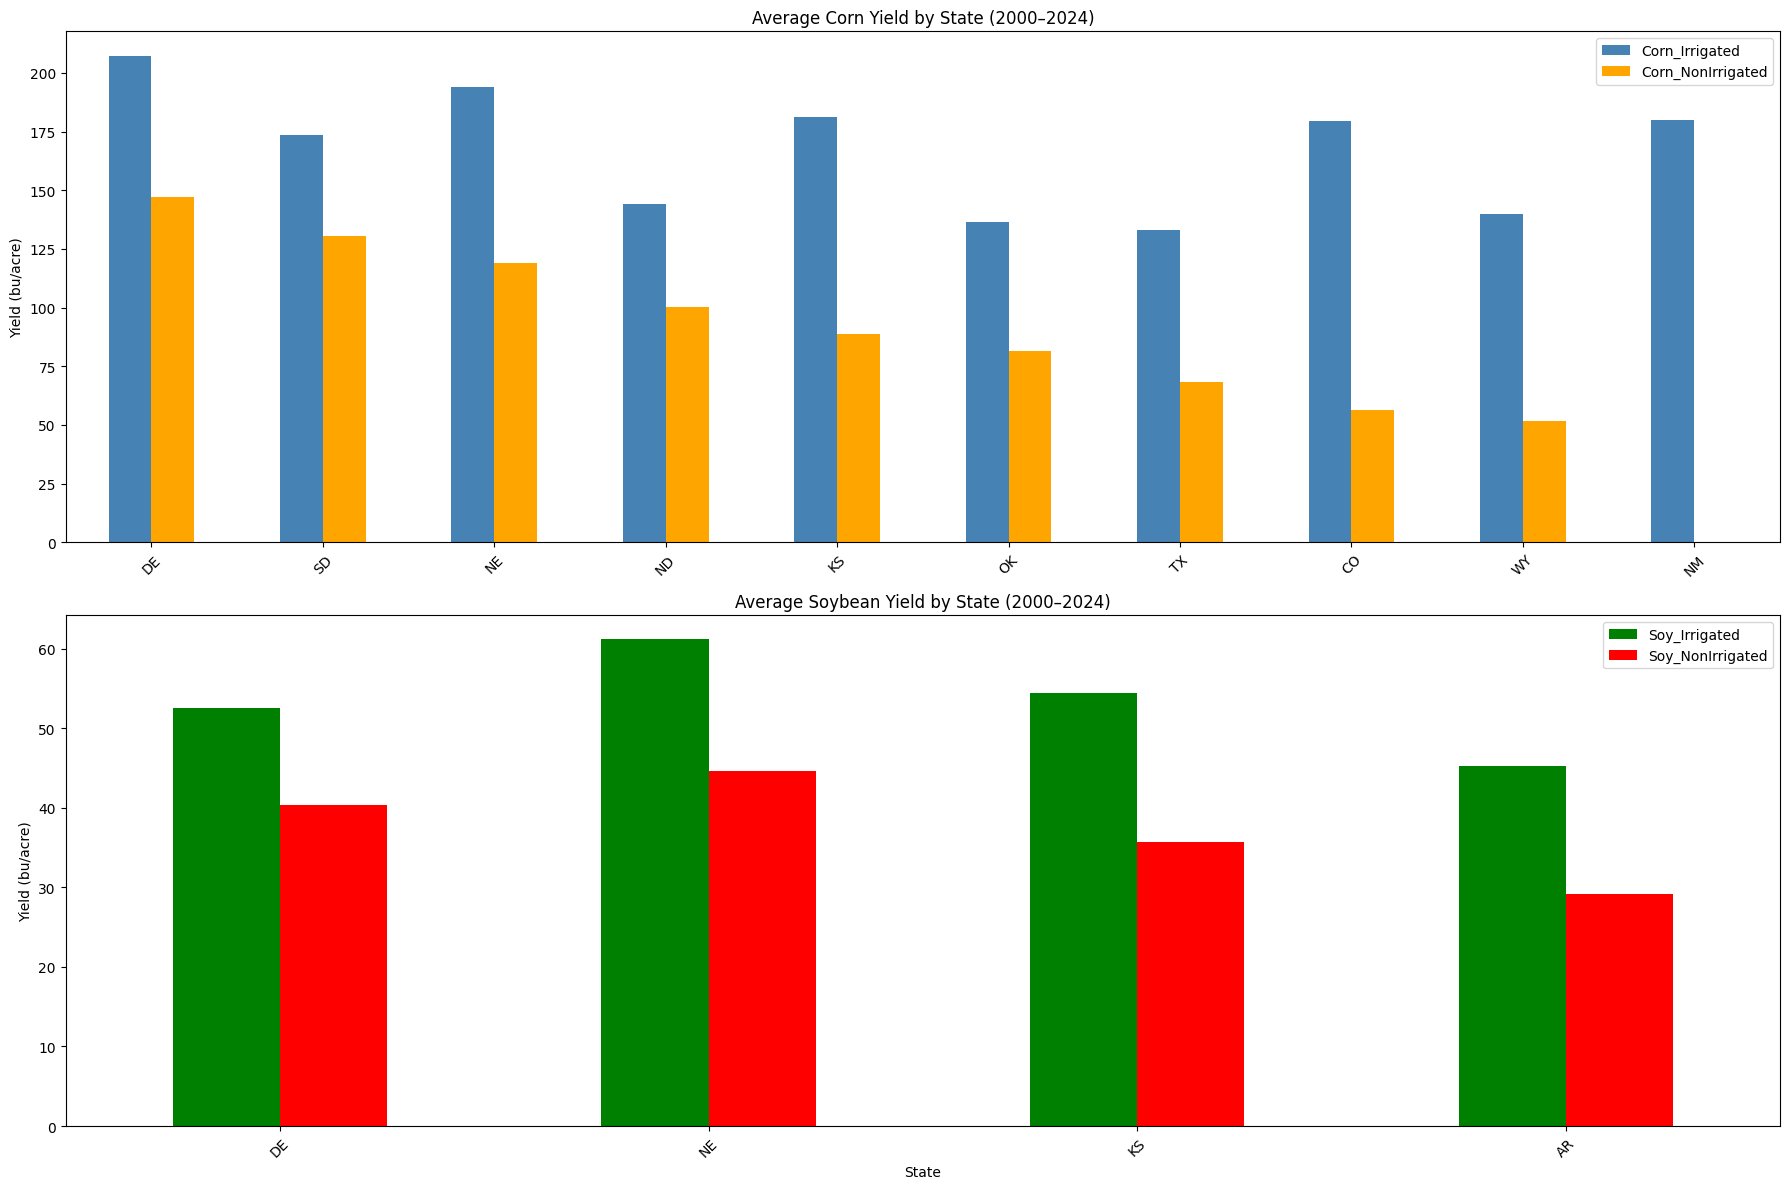

In [42]:
# Crop yield per state - split into two charts for readability
df_state_yield = df_crop_yields.groupby('State')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean().dropna(how='all')
df_state_yield = df_state_yield.sort_values('Corn_NonIrrigated', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Corn
df_state_yield[['Corn_Irrigated', 'Corn_NonIrrigated']].dropna(how='all').plot(
    kind='bar', ax=axes[0], color=['steelblue', 'orange']
)
axes[0].set_title('Average Corn Yield by State (2000–2024)')
axes[0].set_ylabel('Yield (bu/acre)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Soybeans
df_state_yield[['Soy_Irrigated', 'Soy_NonIrrigated']].dropna(how='all').plot(
    kind='bar', ax=axes[1], color=['green', 'red']
)
axes[1].set_title('Average Soybean Yield by State (2000–2024)')
axes[1].set_ylabel('Yield (bu/acre)')
axes[1].set_xlabel('State')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


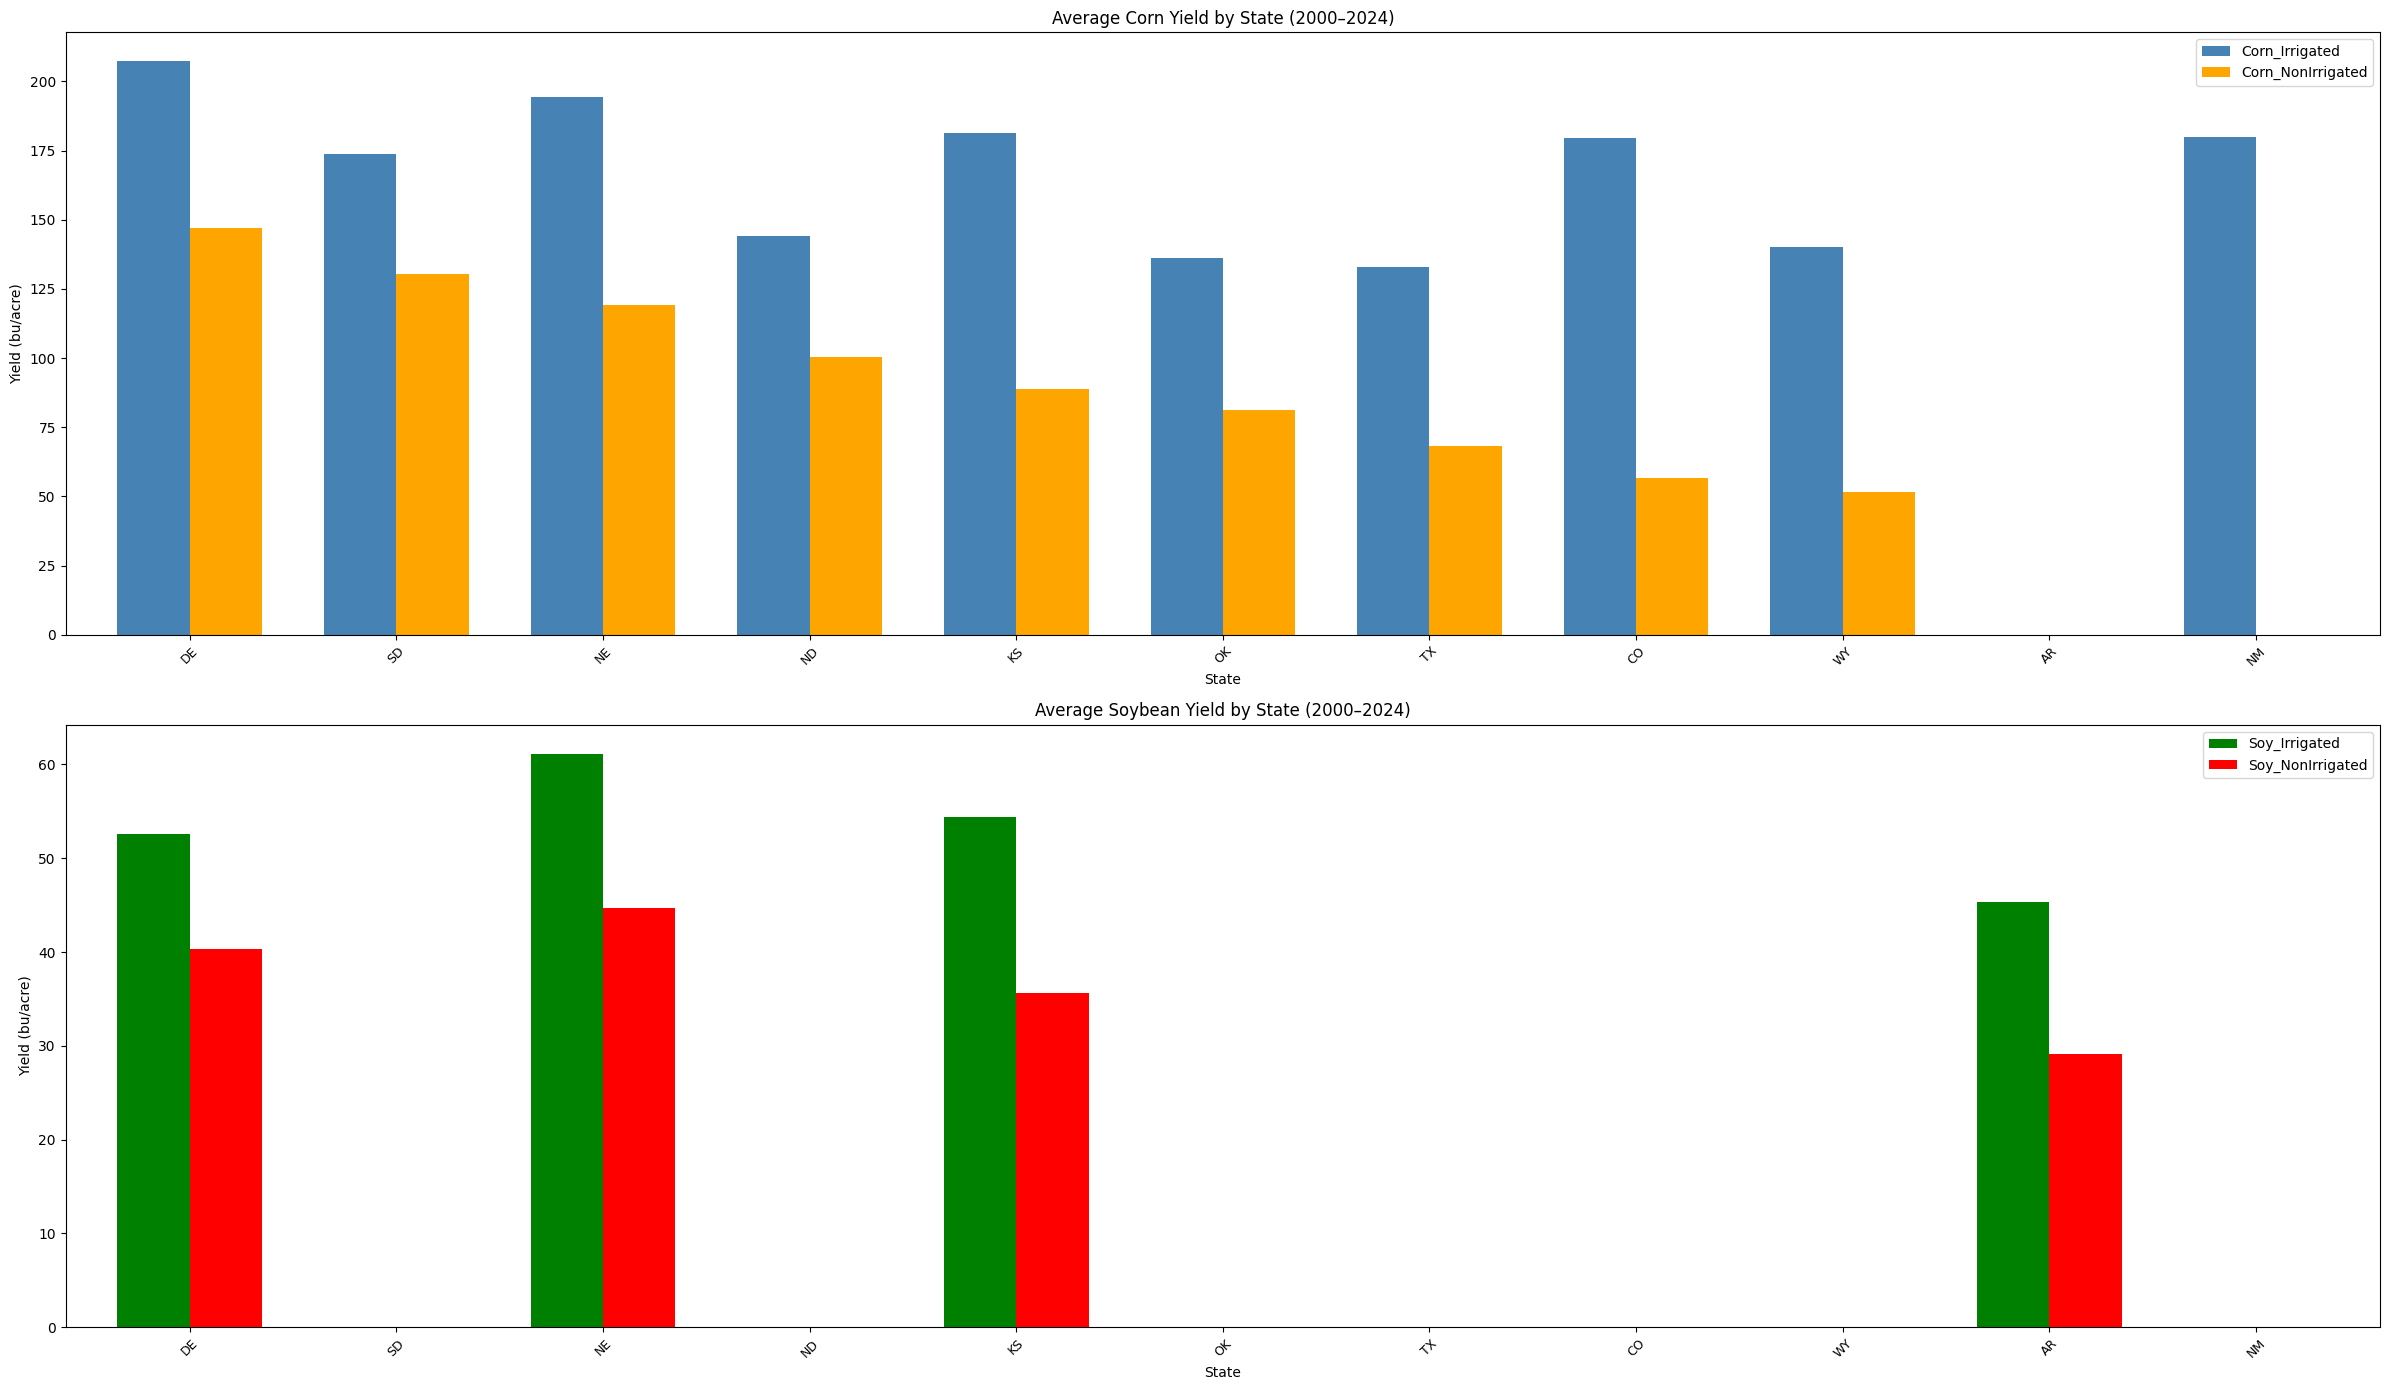

In [43]:
# All states - corn and soybeans split into two charts
df_state_yield = df_crop_yields.groupby('State')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()
df_state_yield = df_state_yield.sort_values('Corn_NonIrrigated', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(24, 14))

df_state_yield[['Corn_Irrigated', 'Corn_NonIrrigated']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'orange'], width=0.7
)
axes[0].set_title('Average Corn Yield by State (2000–2024)')
axes[0].set_ylabel('Yield (bu/acre)')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)

df_state_yield[['Soy_Irrigated', 'Soy_NonIrrigated']].plot(
    kind='bar', ax=axes[1], color=['green', 'red'], width=0.7
)
axes[1].set_title('Average Soybean Yield by State (2000–2024)')
axes[1].set_ylabel('Yield (bu/acre)')
axes[1].set_xlabel('State')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.show()


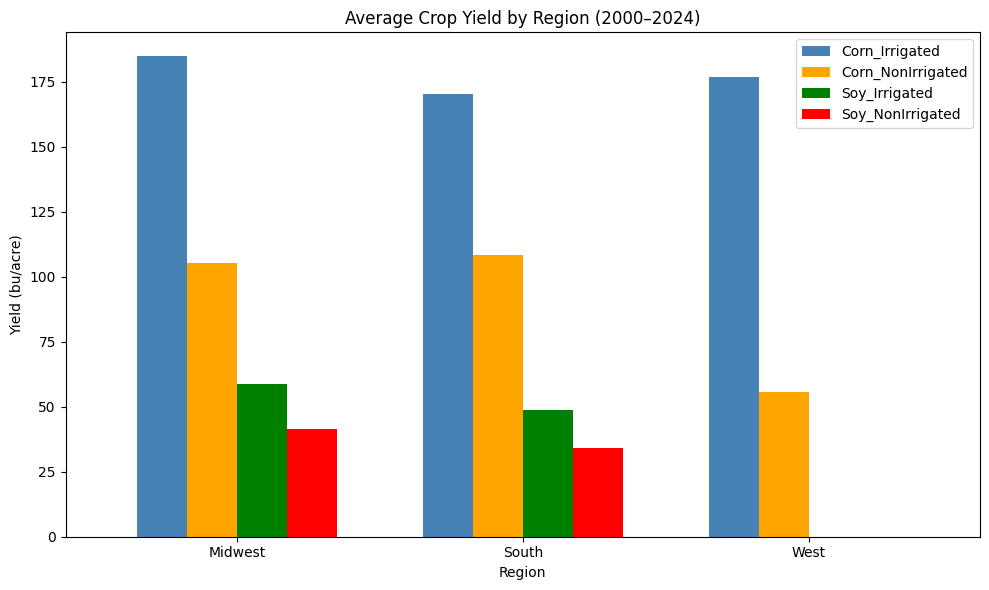

         Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Region                                                                     
Midwest           184.7              105.2           58.8              41.5
South             170.3              108.3           48.6              34.2
West              176.7               55.8            NaN               NaN


In [44]:
# Agricultural output per region
df_state_yield_region = df_crop_yields.copy()
df_state_yield_region['Region'] = df_state_yield_region['State'].map(region_map)
df_state_yield_region = df_state_yield_region.dropna(subset=['Region'])

df_region_yield = df_state_yield_region.groupby('Region')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()

df_region_yield.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'orange', 'green', 'red'], width=0.7)
plt.title('Average Crop Yield by Region (2000–2024)')
plt.ylabel('Yield (bu/acre)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(df_region_yield.round(1).to_string())
